In [1]:
import numpy as np
import pandas as pd
import dill 
from tqdm import tqdm
import time
from scipy.stats import qmc
import random
import scipy.stats as stats
from scipy.stats import multivariate_normal

from Forward_model.generate_IC_fixed_grid import get_generate_IC_fixed_grid
from Forward_model.solution_using_FD import get_solution_using_FD
from Forward_model.linear_interpolation import interpolate_linear,interpolate_linear_fill_value
import os

from sklearn.gaussian_process.kernels import Matern
from Forward_model.cubic_spline_interpolation import interpolate_cubicSpline

In [2]:
import dill
import numpy as np

with open('Forward_model/IC_ws64_wb0_tb14_H2782_a24634_ic.pkl', 'rb') as f:
    ics = dill.load(f)

In [3]:
import matplotlib.pyplot as plt

In [4]:
rs_signal_1 = np.load('Data/case_study/time_series_used/Signal_rsignal_1_smooth.npy')
rs_signal_2 = np.load('Data/case_study/time_series_used/Signal_rsignal_2_smooth.npy')
rs_signal_3 = np.load('Data/case_study/time_series_used/Signal_rsignal_3_smooth.npy')
rs_signal_4 = np.load('Data/case_study/time_series_used/Signal_rsignal_4_smooth.npy')


In [5]:
Realistic_smooth_rsignal_1_1mK_upper_bound=np.load('Results/Realistic_smooth_rsignal_1_1mK_upper_bound.npy')
Realistic_smooth_rsignal_1_1mK_lower_bound=np.load('Results/Realistic_smooth_rsignal_1_1mK_lower_bound.npy')
Realistic_smooth_rsignal_1_1mK_qmean=np.load('Results/Realistic_smooth_rsignal_1_1mK_qmean.npy')

Realistic_smooth_rsignal_2_1mK_upper_bound=np.load('Results/Realistic_smooth_signal_PA1_1_1mK_upper_bound.npy')
Realistic_smooth_rsignal_2_1mK_lower_bound=np.load('Results/Realistic_smooth_signal_PA1_1_1mK_lower_bound.npy')
Realistic_smooth_rsignal_2_1mK_qmean=np.load('Results/Realistic_smooth_signal_PA1_1_1mK_qmean.npy')

Realistic_smooth_rsignal_3_1mK_upper_bound=np.load('Results/Realistic_smooth_rsignal_3_1mK_upper_bound.npy')
Realistic_smooth_rsignal_3_1mK_lower_bound=np.load('Results/Realistic_smooth_rsignal_3_1mK_lower_bound.npy')
Realistic_smooth_rsignal_3_1mK_qmean=np.load('Results/Realistic_smooth_rsignal_3_1mK_qmean.npy')

Realistic_smooth_rsignal_4_1mK_upper_bound=np.load('Results/Realistic_smooth_rsignal_4_1mK_upper_bound.npy')
Realistic_smooth_rsignal_4_1mK_lower_bound=np.load('Results/Realistic_smooth_rsignal_4_1mK_lower_bound.npy')
Realistic_smooth_rsignal_4_1mK_qmean=np.load('Results/Realistic_smooth_rsignal_4_1mK_qmean.npy')

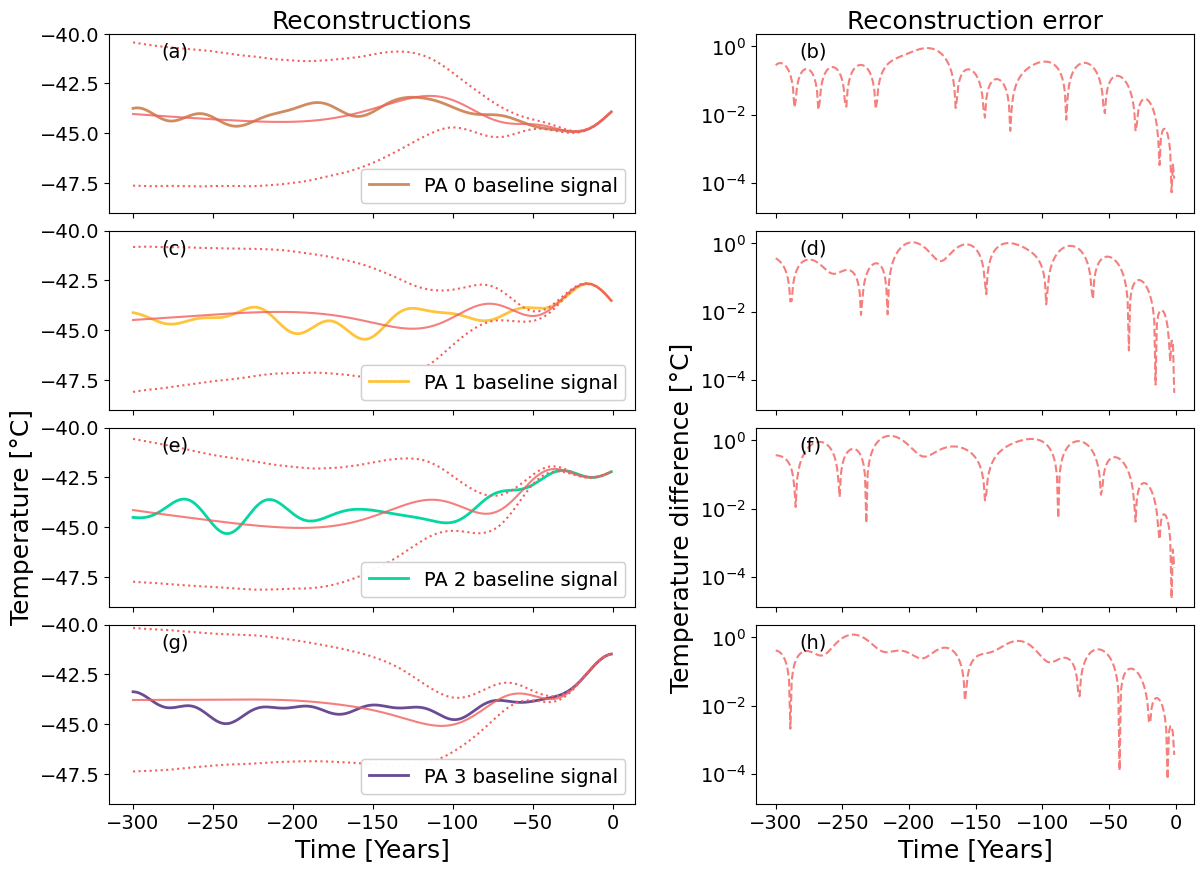

In [6]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

plt.rc('xtick', labelsize=14) 
plt.rc('ytick', labelsize=14)

t_annual_500yr=np.arange(0,500,1)


time_steps=np.load('Forward_model/fwd_times_0_499.npy')

rs_signal_1_annual=interpolate_cubicSpline(x_ref=time_steps,y_ref=rs_signal_1,x_req=t_annual_500yr)
rs_signal_2_annual=interpolate_cubicSpline(x_ref=time_steps,y_ref=rs_signal_2,x_req=t_annual_500yr)
rs_signal_3_annual=interpolate_cubicSpline(x_ref=time_steps,y_ref=rs_signal_3,x_req=t_annual_500yr)
rs_signal_4_annual=interpolate_cubicSpline(x_ref=time_steps,y_ref=rs_signal_4,x_req=t_annual_500yr)

x1=t_annual_500yr -500
signals = [
    rs_signal_1_annual,
    rs_signal_2_annual,
    rs_signal_3_annual,
    rs_signal_4_annual,
]

labels  = ['PA 0 baseline signal', 'PA 1 baseline signal', 'PA 2 baseline signal', 'PA 3 baseline signal']
# sublabels  = [ 'kernel']
colors  = ['#d08c60', '#ffc43d', '#06d6a0', '#6a4c93']
recon_colors  = ['#f25f5c']
sublabels  = ['(a)', '(b)', '(c)', '(d)']
subplotleftlabels  = ['(a)', '(c)','(e)','(g)']
subplotrightlabels  = ['(b)','(d)','(f)','(h)']
others = [
    [Realistic_smooth_rsignal_1_1mK_qmean],
    [Realistic_smooth_rsignal_2_1mK_qmean],
    [Realistic_smooth_rsignal_3_1mK_qmean],
    [Realistic_smooth_rsignal_4_1mK_qmean],
]

ci_upper = [
    [Realistic_smooth_rsignal_1_1mK_upper_bound],
    [Realistic_smooth_rsignal_2_1mK_upper_bound],
    [Realistic_smooth_rsignal_3_1mK_upper_bound],
    [Realistic_smooth_rsignal_4_1mK_upper_bound],
]

ci_lower= [
    [Realistic_smooth_rsignal_1_1mK_lower_bound],
    [Realistic_smooth_rsignal_2_1mK_lower_bound],
    [Realistic_smooth_rsignal_3_1mK_lower_bound],
    [Realistic_smooth_rsignal_4_1mK_lower_bound],
]


fig = plt.figure(figsize=(14, 10))


# Outer layout: left (stacked) + right (single)
outer_gs = GridSpec(1, 2, width_ratios=[1.2, 1], wspace=0.25)

# =========================
# LEFT PANEL: all 4 signals
# =========================
left_gs = GridSpecFromSubplotSpec(
    4, 1,
    subplot_spec=outer_gs[0],
    hspace=0.1
)

left_axes = []

for i in range(4):
    if i == 0:
        ax = fig.add_subplot(left_gs[i])
    else:
        ax = fig.add_subplot(left_gs[i],
                             sharex=left_axes[0],
                             sharey=left_axes[0])

    line_signal,=ax.plot(x1[-300:], signals[i][-300:],color=colors[i], label=labels[i], lw=2)

    first_legend = ax.legend(handles=[line_signal], loc='lower right',fontsize=14)
    ax.add_artist(first_legend)   
    
    line_1,=ax.plot(x1[-300:], others[i][0][-300:],
            color=recon_colors[0], label=sublabels[0],alpha=0.8)
    ax.plot(x1[-300:], ci_upper[i][0][-300:],
            color=recon_colors[0], linestyle='dotted')
    ax.plot(x1[-300:], ci_lower[i][0][-300:],
            color=recon_colors[0], linestyle='dotted')

    ax.text(0.1, 0.95, subplotleftlabels[i], horizontalalignment='left', verticalalignment='top', transform=ax.transAxes,fontsize=14)
    
    # ax.legend(handles=[line_1],loc='lower right',fontsize=14, mode = "expand", ncol = 3,bbox_to_anchor=(0.35, 0, 0.65, 1))
   
    ax.set_ylim(-49, -40)
    left_axes.append(ax)

# Formatting
for ax in left_axes[:-1]:
    plt.setp(ax.get_xticklabels(), visible=False)

left_axes[2].set_ylabel('Temperature [°C]', fontsize=18)
left_axes[-1].set_xlabel('Time [Years]', fontsize=18)

# =========================
# RIGHT PANEL: even signals
# =========================
right_gs = GridSpecFromSubplotSpec(
    4, 1,
    subplot_spec=outer_gs[1],
    hspace=0.1
)

right_axes = []

for i in range(4):
    if i == 0:
        ax = fig.add_subplot(right_gs[i])
    else:
        ax = fig.add_subplot(right_gs[i],
                             sharex=right_axes[0],
                             sharey=right_axes[0])


    ax.plot(x1[-300:], np.abs(others[i][0][-300:]-signals[i][-300:]),
            color=recon_colors[0], label=sublabels[0], alpha=0.8, linestyle='--')

    # ax.legend(loc='lower right',fontsize=14, mode = "expand", ncol = 3,bbox_to_anchor=(0, 0, 0.65, 1))
    
    ax.set_yscale('log')
    ax.set_yticks([1e0, 1e-2, 1e-4], [r"$10^0$", r"$10^{-2}$", r"$10^{-4}$"])
    ax.text(0.1, 0.95, subplotrightlabels[i], horizontalalignment='left', verticalalignment='top', transform=ax.transAxes,fontsize=14)
    

    right_axes.append(ax)

# Formatting
for ax in right_axes[:-1]:
    plt.setp(ax.get_xticklabels(), visible=False)

right_axes[2].set_ylabel('Temperature difference [°C]', fontsize=18)
right_axes[-1].set_xlabel('Time [Years]', fontsize=18)


left_axes[0].text(
    0.5, 1,                  
    'Reconstructions',       
    ha='center', va='bottom',     
    fontsize=18,
    transform=left_axes[0].transAxes
)

right_axes[0].text(
    0.5, 1,                 
    'Reconstruction error',             
    ha='center', va='bottom',
    fontsize=18,
    transform=right_axes[0].transAxes
)

plt.savefig('Figures/fig_baseline_signalsPA0123_reconstructions.png', dpi=300)
plt.show()


In [7]:
import os
import numpy as np
recon_PA1={}
for i in range(40):
    path = f'Results/Realistic_smooth_signal_PA1_{i}_1mK_qmean.npy'

    if os.path.exists(path):
        recon_PA1[i] = np.load(path)
        print(f'Loaded {path}')
        # break

Loaded Results/Realistic_smooth_signal_PA1_1_1mK_qmean.npy
Loaded Results/Realistic_smooth_signal_PA1_2_1mK_qmean.npy
Loaded Results/Realistic_smooth_signal_PA1_4_1mK_qmean.npy
Loaded Results/Realistic_smooth_signal_PA1_6_1mK_qmean.npy
Loaded Results/Realistic_smooth_signal_PA1_7_1mK_qmean.npy
Loaded Results/Realistic_smooth_signal_PA1_11_1mK_qmean.npy
Loaded Results/Realistic_smooth_signal_PA1_12_1mK_qmean.npy
Loaded Results/Realistic_smooth_signal_PA1_13_1mK_qmean.npy
Loaded Results/Realistic_smooth_signal_PA1_14_1mK_qmean.npy
Loaded Results/Realistic_smooth_signal_PA1_16_1mK_qmean.npy
Loaded Results/Realistic_smooth_signal_PA1_17_1mK_qmean.npy
Loaded Results/Realistic_smooth_signal_PA1_18_1mK_qmean.npy
Loaded Results/Realistic_smooth_signal_PA1_19_1mK_qmean.npy
Loaded Results/Realistic_smooth_signal_PA1_20_1mK_qmean.npy
Loaded Results/Realistic_smooth_signal_PA1_23_1mK_qmean.npy
Loaded Results/Realistic_smooth_signal_PA1_24_1mK_qmean.npy
Loaded Results/Realistic_smooth_signal_PA1_25

In [8]:
len(recon_PA1)

28

In [9]:
smooth_rsignal_2_ensemble=np.load('Data/case_study/time_series_used/smooth_rsignal_2_ensemble.npy')

In [10]:
smooth_ensemble_PA1={}
for keys in recon_PA1.keys():
    smooth_ensemble_PA1[keys]=interpolate_cubicSpline(x_ref=time_steps,y_ref=smooth_rsignal_2_ensemble[keys-1],x_req=t_annual_500yr)
    

In [11]:
difference_ensemble_PA1={}
for key in smooth_ensemble_PA1.keys():
    difference_ensemble_PA1[key]=smooth_ensemble_PA1[key]-recon_PA1[key]
difference_ensemble_PA1_array=np.array(list(difference_ensemble_PA1.values()))
    

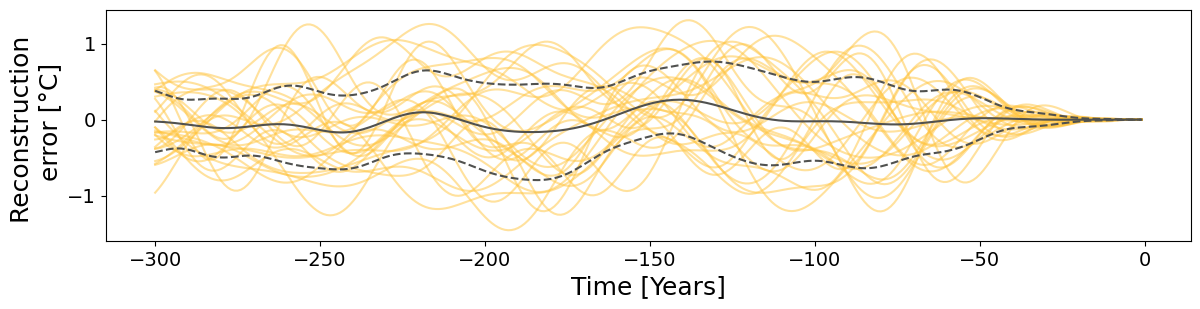

In [12]:
fig = plt.figure(figsize=(14, 3))
for key in difference_ensemble_PA1.keys():
    plt.plot(x1[-300:], difference_ensemble_PA1[key][-300:], color='#ffc43d', alpha=0.5)

plt.plot(x1[-300:],difference_ensemble_PA1_array.mean(axis=0)[-300:], color='#50514f')
plt.plot(x1[-300:],(difference_ensemble_PA1_array.mean(axis=0)+difference_ensemble_PA1_array.std(axis=0))[-300:], color='#50514f', linestyle='--')
plt.plot(x1[-300:],(difference_ensemble_PA1_array.mean(axis=0)-difference_ensemble_PA1_array.std(axis=0))[-300:], color='#50514f',linestyle='--')
plt.ylabel('Reconstruction \n error [°C]', fontsize=18)
plt.xlabel('Time [Years]', fontsize=18)
# plt.savefig('Figures/fig_err_ensemble_reconstructions.png', dpi=300)

In [13]:
sqrt_mean_sq_diff_40=np.load('Data/case_study/approximation_uncertainty/approx_uncertainty_rmsq_int40eq.npy')
measured_depths_40eq=np.linspace(0,200,40)

In [14]:
r_signal_1 = np.load('Data/case_study/time_series_used/Signal_rsignal_1.npy')
r_signal_2 = np.load('Data/case_study/time_series_used/Signal_rsignal_2.npy')
r_signal_3 = np.load('Data/case_study/time_series_used/Signal_rsignal_3.npy')
r_signal_4 = np.load('Data/case_study/time_series_used/Signal_rsignal_4.npy')



In [15]:
Realistic_rsignal_1_1mK_upper_bound=np.load('Results/Realistic_org_rsignal_1_aprx_0mK_upper_bound.npy')
Realistic_rsignal_1_1mK_lower_bound=np.load('Results/Realistic_org_rsignal_1_aprx_0mK_lower_bound.npy')
Realistic_rsignal_1_1mK_qmean=np.load('Results/Realistic_org_rsignal_1_aprx_0mK_qmean.npy')

Realistic_rsignal_2_1mK_upper_bound=np.load('Results/Realistic_org_rsignal_2_aprx_0mK_upper_bound.npy')
Realistic_rsignal_2_1mK_lower_bound=np.load('Results/Realistic_org_rsignal_2_aprx_0mK_lower_bound.npy')
Realistic_rsignal_2_1mK_qmean=np.load('Results/Realistic_org_rsignal_2_aprx_0mK_qmean.npy')


Realistic_rsignal_3_1mK_upper_bound=np.load('Results/Realistic_org_rsignal_3_aprx_0mK_upper_bound.npy')
Realistic_rsignal_3_1mK_lower_bound=np.load('Results/Realistic_org_rsignal_3_aprx_0mK_lower_bound.npy')
Realistic_rsignal_3_1mK_qmean=np.load('Results/Realistic_org_rsignal_3_aprx_0mK_qmean.npy')

Realistic_rsignal_4_1mK_upper_bound=np.load('Results/Realistic_org_rsignal_4_aprx_0mK_upper_bound.npy')
Realistic_rsignal_4_1mK_lower_bound=np.load('Results/Realistic_org_rsignal_4_aprx_0mK_lower_bound.npy')
Realistic_rsignal_4_1mK_qmean=np.load('Results/Realistic_org_rsignal_4_aprx_0mK_qmean.npy')


Text(0.5, 0, 'Time [Years]')

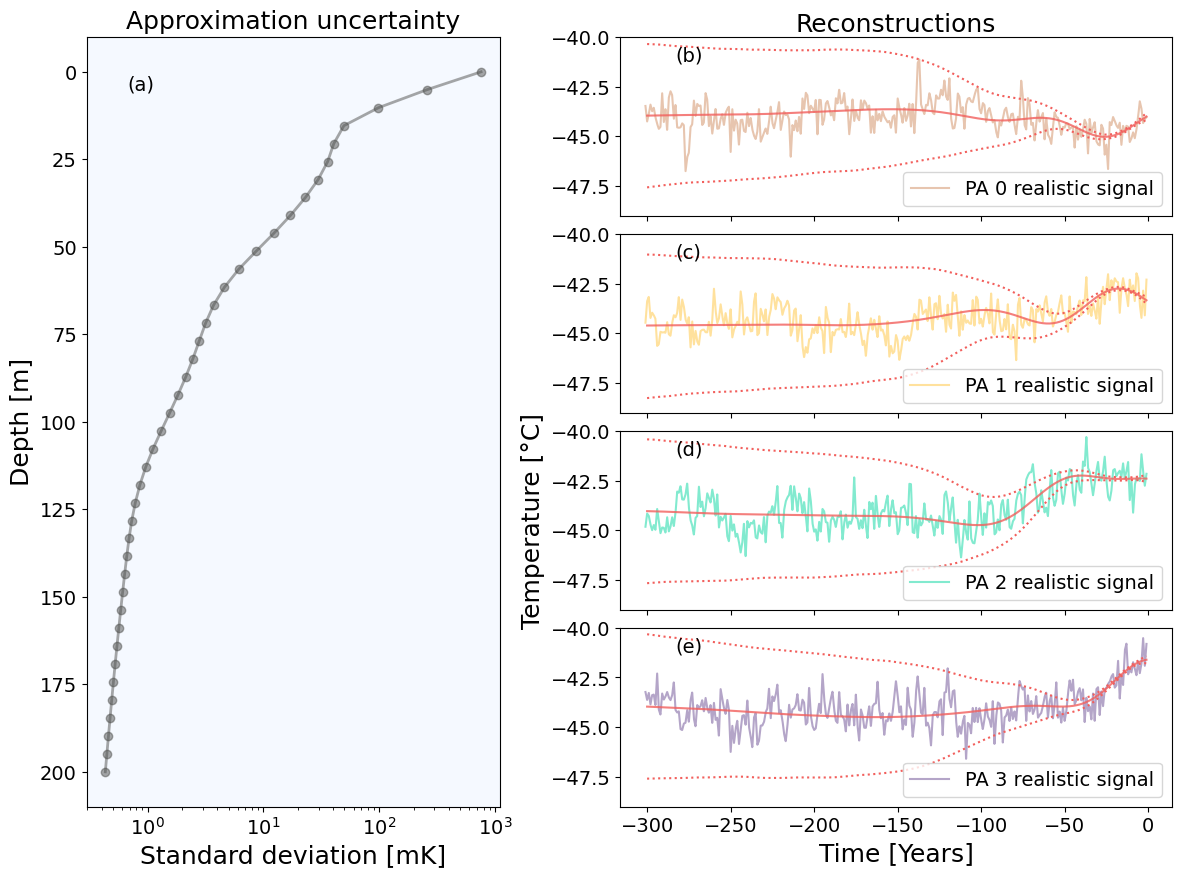

In [17]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

fig = plt.figure(figsize=(14, 10))

plt.rc('xtick', labelsize=14) 
plt.rc('ytick', labelsize=14)

time_steps=np.load('Forward_model/fwd_times_0_499.npy')
outer_gs = GridSpec(1, 2, width_ratios=[0.75, 1], wspace=0.25)

right_gs = GridSpecFromSubplotSpec(
    4, 1,
    subplot_spec=outer_gs[1],
    hspace=0.1
)

signals = [r_signal_1, r_signal_2, r_signal_3, r_signal_4]
labels  = ['PA 0 realistic signal', 'PA 1 realistic signal', 'PA 2 realistic signal', 'PA 3 realistic signal']
colors  = ['#d08c60', '#ffc43d', '#06d6a0', '#6a4c93']
recon_colors  = ['#f25f5c']
alphas=[1,1,1,1]
subplotlabels  = ['(a)', '(b)', '(c)', '(d)','(e)']

others = [
    [Realistic_rsignal_1_1mK_qmean],
    [Realistic_rsignal_2_1mK_qmean],
    [Realistic_rsignal_3_1mK_qmean],
    [Realistic_rsignal_4_1mK_qmean],
]

ci_upper = [
    [Realistic_rsignal_1_1mK_upper_bound],
    [Realistic_rsignal_2_1mK_upper_bound],
    [Realistic_rsignal_3_1mK_upper_bound],
    [Realistic_rsignal_4_1mK_upper_bound],
]

ci_lower= [
    [Realistic_rsignal_1_1mK_lower_bound],
    [Realistic_rsignal_2_1mK_lower_bound],
    [Realistic_rsignal_3_1mK_lower_bound],
    [Realistic_rsignal_4_1mK_lower_bound],
]

# =========================
ax_1 = fig.add_subplot(outer_gs[0])

# ax_1.plot(sqrt_mean_sq_diff[:51]*1000, depths_fwd[:51], color='#50514f', linewidth=2, label='approximation error')
ax_1.plot(sqrt_mean_sq_diff_40*1000, measured_depths_40eq, color='#50514f', linewidth=2, label='approximation error', linestyle='-', marker='o', alpha=0.5)

ax_1.invert_yaxis()
ax_1.set_xscale('log')
ax_1.set_xlabel('Standard deviation [mK]', fontsize=18)
ax_1.set_ylabel('Depth [m]', fontsize=18)
ax_1.text(0.1, 0.95, subplotlabels[0], horizontalalignment='left', verticalalignment='top', transform=ax_1.transAxes,fontsize=14)
# ax_1.legend(loc='lower right',fontsize=14)
ax_1.set_title('Approximation uncertainty', fontsize=18)
ax_1.set_facecolor('#F5F9FF') 
right_axes = []

for i in range(4):
    if i == 0:
        ax = fig.add_subplot(right_gs[i])
    else:
        ax = fig.add_subplot(right_gs[i],
                             sharex=right_axes[0],
                             sharey=right_axes[0])

    ax.plot(time_steps[-300*16:] - 500, signals[i][-300*16:],
            color=colors[i], label=labels[i], alpha=0.5)

    ax.plot(x1[-300:], others[i][0][-300:],
            color=recon_colors[0],alpha=0.8)
    ax.plot(x1[-300:], ci_upper[i][0][-300:],
            color=recon_colors[0], linestyle='dotted')
    ax.plot(x1[-300:], ci_lower[i][0][-300:],
            color=recon_colors[0], linestyle='dotted')

    ax.text(0.1, 0.95, subplotlabels[i+1], horizontalalignment='left', verticalalignment='top', transform=ax.transAxes,fontsize=14)
    ax.legend(loc='lower right',fontsize=14)
    ax.set_ylim(-49,-40)
    right_axes.append(ax)
    
# Formatting
for ax in right_axes[:-1]:
    plt.setp(ax.get_xticklabels(), visible=False)

right_axes[0].text(
    0.5, 1,                 
    'Reconstructions',            
    ha='center', va='bottom',
    fontsize=18,
    transform=right_axes[0].transAxes
)


right_axes[2].set_ylabel('Temperature [°C]', fontsize=18)
right_axes[-1].set_xlabel('Time [Years]', fontsize=18)

# plt.savefig('Figures/fig_noisy_signal_reconstructions.png', dpi=300)

In [18]:
Realistic_anomaly_signal_rsignal1_1mK_upper_bound=np.load('Results/Realistic_anomaly_signal_rsignal1_1mK_upper_bound.npy')
Realistic_anomaly_signal_rsignal1_1mK_lower_bound=np.load('Results/Realistic_anomaly_signal_rsignal1_1mK_lower_bound.npy')
Realistic_anomaly_signal_rsignal1_1mK_qmean=np.load('Results/Realistic_anomaly_signal_rsignal1_1mK_qmean.npy')

Realistic_anomaly_signal_rsignal2_1mK_upper_bound=np.load('Results/Realistic_anomaly_signal_rsignal2_1mK_upper_bound.npy')
Realistic_anomaly_signal_rsignal2_1mK_lower_bound=np.load('Results/Realistic_anomaly_signal_rsignal2_1mK_lower_bound.npy')
Realistic_anomaly_signal_rsignal2_1mK_qmean=np.load('Results/Realistic_anomaly_signal_rsignal2_1mK_qmean.npy')

Realistic_anomaly_signal_rsignal3_1mK_upper_bound=np.load('Results/Realistic_anomaly_signal_rsignal3_1mK_upper_bound.npy')
Realistic_anomaly_signal_rsignal3_1mK_lower_bound=np.load('Results/Realistic_anomaly_signal_rsignal3_1mK_lower_bound.npy')
Realistic_anomaly_signal_rsignal3_1mK_qmean=np.load('Results/Realistic_anomaly_signal_rsignal3_1mK_qmean.npy')

Realistic_anomaly_signal_rsignal4_1mK_upper_bound=np.load('Results/Realistic_anomaly_signal_rsignal4_1mK_upper_bound.npy')
Realistic_anomaly_signal_rsignal4_1mK_lower_bound=np.load('Results/Realistic_anomaly_signal_rsignal4_1mK_lower_bound.npy')
Realistic_anomaly_signal_rsignal4_1mK_qmean=np.load('Results/Realistic_anomaly_signal_rsignal4_1mK_qmean.npy')

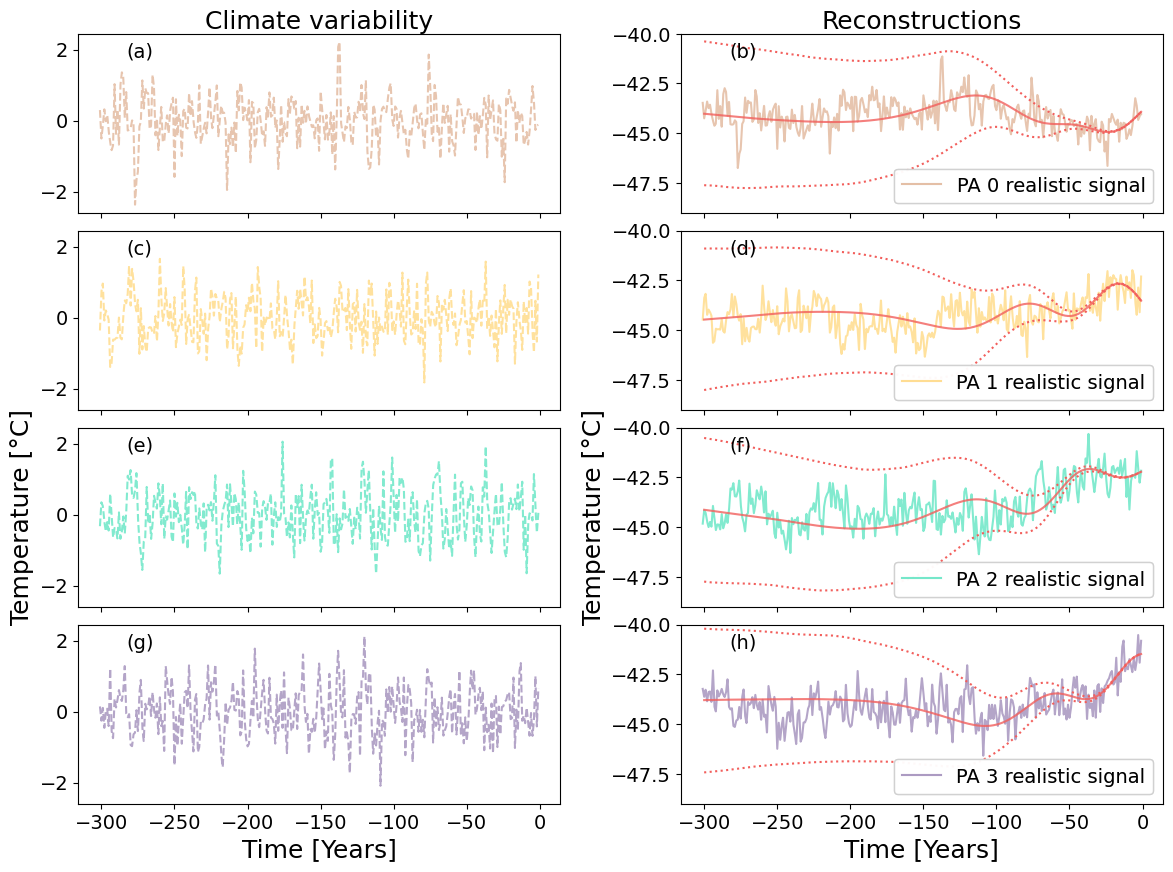

In [20]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

plt.rc('xtick', labelsize=14) 
plt.rc('ytick', labelsize=14)

t_annual_500yr=np.arange(0,500,1)


time_steps=np.load('Forward_model/fwd_times_0_499.npy')

rs_signal_1_annual=interpolate_cubicSpline(x_ref=time_steps,y_ref=rs_signal_1,x_req=t_annual_500yr)
rs_signal_2_annual=interpolate_cubicSpline(x_ref=time_steps,y_ref=rs_signal_2,x_req=t_annual_500yr)
rs_signal_3_annual=interpolate_cubicSpline(x_ref=time_steps,y_ref=rs_signal_3,x_req=t_annual_500yr)
rs_signal_4_annual=interpolate_cubicSpline(x_ref=time_steps,y_ref=rs_signal_4,x_req=t_annual_500yr)

x1=t_annual_500yr -500

r_signal_1_anomaly=r_signal_1-rs_signal_1
r_signal_2_anomaly=r_signal_2-rs_signal_2
r_signal_3_anomaly=r_signal_3-rs_signal_3
r_signal_4_anomaly=r_signal_4-rs_signal_4

anomalies = [
    r_signal_1_anomaly,
    r_signal_2_anomaly,
    r_signal_3_anomaly,
    r_signal_4_anomaly,
]

labels_noise  = ['PA 0 variability', 'PA 1 variability', 'PA 2 variability', 'PA 3 variability']

labels  = ['PA 0 realistic signal', 'PA 1 realistic signal', 'PA 2 realistic signal', 'PA 3 realistic signal']
# sublabels  = [ 'kernel']
colors  = ['#d08c60', '#ffc43d', '#06d6a0', '#6a4c93']
recon_colors  = ['#f25f5c']
subplotrightlabels  = ['(a)', '(c)','(e)','(g)']
subplotleftlabels  = ['(b)','(d)','(f)','(h)']
others = [
    [Realistic_anomaly_signal_rsignal1_1mK_qmean],
    [Realistic_anomaly_signal_rsignal2_1mK_qmean],
    [Realistic_anomaly_signal_rsignal3_1mK_qmean],
    [Realistic_anomaly_signal_rsignal4_1mK_qmean],
]

ci_upper = [
    [Realistic_anomaly_signal_rsignal1_1mK_upper_bound],
    [Realistic_anomaly_signal_rsignal2_1mK_upper_bound],
    [Realistic_anomaly_signal_rsignal3_1mK_upper_bound],
    [Realistic_anomaly_signal_rsignal4_1mK_upper_bound],
]

ci_lower= [
    [Realistic_anomaly_signal_rsignal1_1mK_lower_bound],
    [Realistic_anomaly_signal_rsignal2_1mK_lower_bound],
    [Realistic_anomaly_signal_rsignal3_1mK_lower_bound],
    [Realistic_anomaly_signal_rsignal4_1mK_lower_bound],
]


fig = plt.figure(figsize=(14, 10))


# Outer layout: left (stacked) + right (single)
outer_gs = GridSpec(1, 2, width_ratios=[1, 1], wspace=0.25)

# =========================
# LEFT PANEL: all 4 signals
# =========================
left_gs = GridSpecFromSubplotSpec(
    4, 1,
    subplot_spec=outer_gs[1],
    hspace=0.1
)

left_axes = []

for i in range(4):
    if i == 0:
        ax = fig.add_subplot(left_gs[i])
    else:
        ax = fig.add_subplot(left_gs[i],
                             sharex=left_axes[0],
                             sharey=left_axes[0])

    line_signal,=ax.plot(time_steps[-300*16:]-500, signals[i][-300*16:],color=colors[i], label=labels[i], alpha=0.5)

    first_legend = ax.legend(handles=[line_signal], loc='lower right',fontsize=14)
    ax.add_artist(first_legend)   
    
    line_1,=ax.plot(x1[-300:], others[i][0][-300:],
            color=recon_colors[0], label=sublabels[0],alpha=0.8)
    ax.plot(x1[-300:], ci_upper[i][0][-300:],
            color=recon_colors[0], linestyle='dotted')
    ax.plot(x1[-300:], ci_lower[i][0][-300:],
            color=recon_colors[0], linestyle='dotted')

    ax.text(0.1, 0.95, subplotleftlabels[i], horizontalalignment='left', verticalalignment='top', transform=ax.transAxes,fontsize=14)
    
    # ax.legend(handles=[line_1],loc='lower right',fontsize=14, mode = "expand", ncol = 3,bbox_to_anchor=(0.35, 0, 0.65, 1))
   
    ax.set_ylim(-49, -40)
    left_axes.append(ax)

# Formatting
for ax in left_axes[:-1]:
    plt.setp(ax.get_xticklabels(), visible=False)

left_axes[2].set_ylabel('Temperature [°C]', fontsize=18)
left_axes[-1].set_xlabel('Time [Years]', fontsize=18)

# =========================
# RIGHT PANEL: even signals
# =========================
right_gs = GridSpecFromSubplotSpec(
    4, 1,
    subplot_spec=outer_gs[0],
    hspace=0.1
)

right_axes = []

for i in range(4):
    if i == 0:
        ax = fig.add_subplot(right_gs[i])
    else:
        ax = fig.add_subplot(right_gs[i],
                             sharex=right_axes[0],
                             sharey=right_axes[0])


    ax.plot(time_steps[-300*16:]-500, anomalies[i][-300*16:],
            color=colors[i], label=sublabels[0], alpha=0.5, linestyle='--')

    # ax.legend(loc='lower right',fontsize=14, mode = "expand", ncol = 3,bbox_to_anchor=(0, 0, 0.65, 1))

    ax.text(0.1, 0.95, subplotrightlabels[i], horizontalalignment='left', verticalalignment='top', transform=ax.transAxes,fontsize=14)
    

    right_axes.append(ax)

# Formatting
for ax in right_axes[:-1]:
    plt.setp(ax.get_xticklabels(), visible=False)

right_axes[2].set_ylabel('Temperature [°C]', fontsize=18)
right_axes[-1].set_xlabel('Time [Years]', fontsize=18)


left_axes[0].text(
    0.5, 1,                  
    'Reconstructions',     
    ha='center', va='bottom',    
    fontsize=18,
    transform=left_axes[0].transAxes
)

right_axes[0].text(
    0.5, 1,                  
    'Climate variability',         
    ha='center', va='bottom',
    fontsize=18,
    transform=right_axes[0].transAxes
)

# plt.savefig('Figures/fig_known_anomaly_reconstructions.png', dpi=300)
plt.show()
